In [ ]:
# v101
# v101 = v100 +
#                Mais augmentação na Biliary_Leaks
#                early_stopping_patience = 20



# ── Hiperparâmetros globais ─────────────────────────────────────────────────
INPUT_IMAGE_SIZE = (256, 256)   # Original = (512, 512); (256, 256) é o recomendado para imagens médicas com detalhes finos
BATCH_SIZE       = 16           # Original = 4, passamos para 8 porque gradientes mais estáveis
NUM_WORKERS      = 0            # Original
EPOCHS           = 80
LEARNING_RATE    = 3e-4
WEIGHT_DECAY     = 1e-4
# ───────────────────────────────────────────────────────────────────────────

In [2]:
version_file = 'v101'

# DenseNet training — v101 = v100 + augmentation Biliary_Leaks class + early_stopping_patience = 20
Melhorias face à v0:
- **AdamW + OneCycleLR** (convergência mais rápida e regularização implícita)
- **FocalLoss + CrossEntropy com class weights e label smoothing** (combate desequilíbrio de classes)
- **Mixup augmentation** (regularização forte, reduz overfitting)
- **Augmentações mais agressivas** no treino (flip H/V, rotação até 30°, shift/scale de intensidade)
- **augmentation na classe Biliary_Leaks**
- **Test-Time Augmentation (TTA)** na inferência
- **Threshold tuning por classe** no val set antes de avaliar o test
- **Early stopping patience=20** com restauro dos melhores pesos
- **Gradient clipping** para estabilidade
- **CLAHE (Contrast Limited Adaptive Histogram Equalization)** para melhorar o contraste local das imagens médicas. Processa as imagens do dataset original e coloca a "versão CLAHE" na pasta dataset_CLAHE

In [3]:
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                               RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                               RandFlip, RandShiftIntensity, RandScaleIntensity,
                               ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config
from monai.networks.nets import DenseNet121
from monai.losses import FocalLoss

import numpy as np
import os
import copy
import cv2
import random
from datetime import datetime
from pathlib import Path
from collections import Counter

from PIL import Image
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

from tqdm import tqdm

import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()

c:\Users\carlo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MONAI version: 1.5.2
Numpy version: 2.4.3
Pytorch version: 2.11.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: c:\Users\<username>\AppData\Local\Programs\Python\Python312\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.1
Pillow version: 12.2.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: 6.0.0
TorchVision version: 0.26.0+cu130
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.1
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALL

# CLAHE
Processa as imagens do dataset original e coloca a "versão CLAHE" na pasta dataset_CLAHE.

In [4]:
INPUT_DIR = "dataset"
OUTPUT_DIR = "dataset_CLAHE"

os.makedirs(OUTPUT_DIR, exist_ok=True)

splits = ["train", "val", "test"]

for split in splits:

    split_input = os.path.join(INPUT_DIR, split)
    split_output = os.path.join(OUTPUT_DIR, split)

    os.makedirs(split_output, exist_ok=True)

    classes = os.listdir(split_input)

    for cls in classes:

        input_class_dir = os.path.join(split_input, cls)
        output_class_dir = os.path.join(split_output, cls)

        os.makedirs(output_class_dir, exist_ok=True)

        image_files = os.listdir(input_class_dir)

        print(f"Processing {split}/{cls}...")

        for image_name in tqdm(image_files):

            input_path = os.path.join(
                input_class_dir,
                image_name
            )

            output_path = os.path.join(
                output_class_dir,
                image_name
            )

            img = cv2.imread(
                input_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is None:
                continue

            clahe = cv2.createCLAHE(
                clipLimit=2.0,
                tileGridSize=(8,8)
            )

            img_clahe = clahe.apply(img)

            cv2.imwrite(
                output_path,
                img_clahe
            )

print("CLAHE preprocessing completed.")

Processing train/Biliary_Leaks...


100%|██████████| 110/110 [00:00<00:00, 177.56it/s]


Processing train/Lithiasis...


100%|██████████| 505/505 [00:02<00:00, 176.15it/s]


Processing train/Normal...


...

Processing test/Normal...


100%|██████████| 43/43 [00:00<00:00, 145.46it/s]


Processing test/Stricture...


100%|██████████| 84/84 [00:00<00:00, 180.95it/s]

CLAHE preprocessing completed.


In [5]:
# Pasta para guardar os modelos
model_path = "./models/MIA_AP_my_models"

if not os.path.exists(model_path):
    os.makedirs(model_path)
    print(f"Diretório {model_path} criado com sucesso!")

In [6]:
base_dir   = './dataset_clahe'
model_name = model_path + "/densenet.pth"

In [7]:
# Versionamento de modelo com timestamp
def get_versioned_model_name(base_path: str) -> str:
    """
    Gera um nome de ficheiro versionado com timestamp.
    Ex: ./models/MIA_AP_my_models/densenet_v1_20260505_101530.pth
    """
    base = Path(base_path)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    new_name = f"{base.stem}_{version_file}_{timestamp}{base.suffix}"
    return str(base.with_name(new_name))

print(get_versioned_model_name(model_name))

models\MIA_AP_my_models\densenet_v101_20260512_004926.pth


In [8]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [9]:
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train'))
                      if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)
print(f"Classes ({num_class}): {class_names}")

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
            os.path.join(class_dir, x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train count = 1067
Val count = 234
Test count = 267


In [10]:
# Calcular class weights para lidar com desequilíbrio entre classes
train_labels  = data['train']['labels']
label_counts  = Counter(train_labels)
total         = len(train_labels)
class_weights = torch.tensor(
    [total / (num_class * label_counts[i]) for i in range(num_class)],
    dtype=torch.float32
)
print("Class weights:", class_weights)

Class weights: tensor([2.4250, 0.5282, 1.3541, 1.0461])


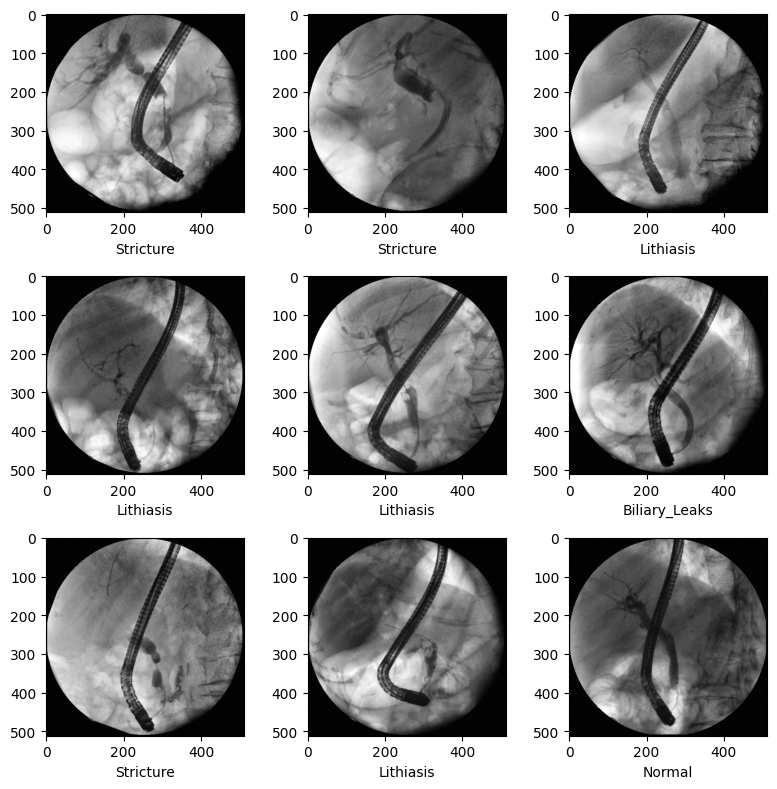

In [11]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()

----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


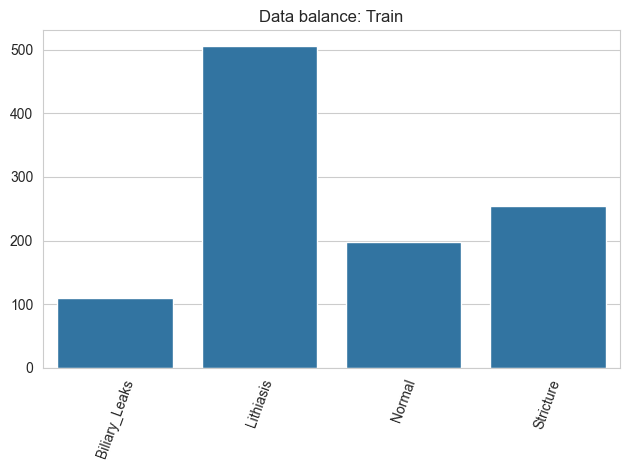

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


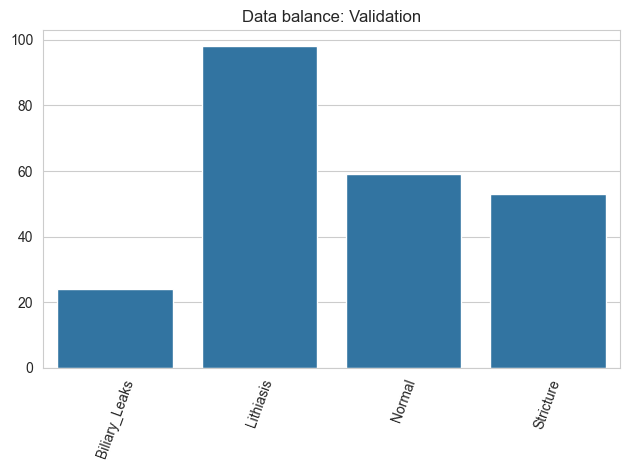

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


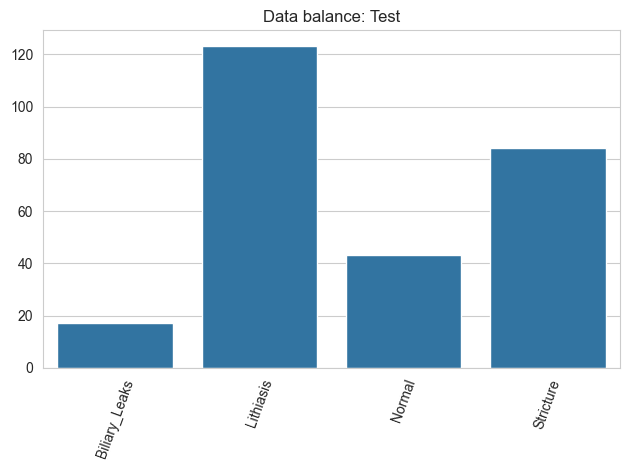

In [12]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext = [class_names[n] for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico = sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')

## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to INPUT_IMAGE_SIZE.

In [13]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

# Treino: augmentações mais agressivas para melhor generalização
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize(INPUT_IMAGE_SIZE),
    # Geométricas
    RandRotate(range_x=30, prob=0.6),           # era 15°/0.5 → mais rotação
    RandZoom(min_zoom=0.85, max_zoom=1.15, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.5),         # flip vertical (novo)
    RandFlip(spatial_axis=1, prob=0.5),         # flip horizontal (novo)
    # Intensidade
    RandAdjustContrast(prob=0.5, gamma=(0.7, 1.5)),
    RandShiftIntensity(offsets=0.15, prob=0.4), # novo
    RandScaleIntensity(factors=0.2, prob=0.4),  # novo
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.02),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize(INPUT_IMAGE_SIZE),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

# Transforms adicionais para TTA (Test-Time Augmentation)
tta_transforms_list = [
    val_transforms,  # original — sem augmentação
    Compose([
        LoadImage(image_only=True), EnsureChannelFirst(),
        Resize(INPUT_IMAGE_SIZE), RandFlip(spatial_axis=1, prob=1.0),
        NormalizeIntensity(), Lambda(repeat_if_needed), ToTensor()
    ]),
    Compose([
        LoadImage(image_only=True), EnsureChannelFirst(),
        Resize(INPUT_IMAGE_SIZE), RandFlip(spatial_axis=0, prob=1.0),
        NormalizeIntensity(), Lambda(repeat_if_needed), ToTensor()
    ]),
    Compose([
        LoadImage(image_only=True), EnsureChannelFirst(),
        Resize(INPUT_IMAGE_SIZE), RandRotate(range_x=15, prob=1.0),
        NormalizeIntensity(), Lambda(repeat_if_needed), ToTensor()
    ]),
]

act       = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [14]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]


train_ds     = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

val_ds     = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

test_ds     = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

## Model
Instantiate a DenseNet121 backbone (pretrained) and adapt the classifier head to the number of classes.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
print(device)

cuda


In [17]:
model = DenseNet121(
    spatial_dims=2,       # 2D images
    in_channels=3,
    out_channels=num_class,
    pretrained=True
).to(device)

## Mixup Augmentation

In [19]:
def mixup_data(x, y, alpha=0.4):
    """Aplica Mixup: combina linearmente dois exemplos aleatórios do batch."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss com Mixup: combinação linear das duas losses."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

## Loss Function — FocalLoss + CrossEntropy com Label Smoothing e Class Weights

In [20]:
class WeightedCELabelSmoothing(nn.Module):
    """
    CrossEntropy com label smoothing e class weights.
    Label smoothing evita overconfidence; class weights compensam desequilíbrio.
    """
    def __init__(self, weight, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, pred, target):
        n_classes    = pred.size(1)
        smooth_target = torch.zeros_like(pred).scatter_(1, target.view(-1, 1).long(), 1)
        smooth_target = smooth_target * (1 - self.smoothing) + self.smoothing / n_classes
        log_prob      = F.log_softmax(pred, dim=1)
        w             = self.weight.to(pred.device)[target.long()].unsqueeze(1)
        return -(smooth_target * log_prob * w).sum(dim=1).mean()


focal_loss = FocalLoss(to_onehot_y=True, gamma=2.0)
ce_smooth  = WeightedCELabelSmoothing(weight=class_weights, smoothing=0.1)

def combined_loss(pred, target):
    """60% FocalLoss + 40% CrossEntropy com label smoothing e class weights."""
    fl = focal_loss(pred, target.unsqueeze(1).long())
    ce = ce_smooth(pred, target)
    return 0.6 * fl + 0.4 * ce

## Training
The `train_model` function runs the training loop with Mixup, early stopping, OneCycleLR scheduling and logging of metrics (F1, AUC).

In [21]:
def train_model(train_dl, val_dl, model, optimizer, epochs, name, scheduler):
    early_stopping_patience  = 20
    epochs_without_improvement = 0
    liveloss        = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric     = -1
    best_metric_epoch = -1
    best_weights    = None
    metric_values   = []

    f1_metric   = MulticlassF1Score(num_classes=num_class, average='macro').to(device)
    auc_metric  = ROCAUCMetric()
    scaler = torch.amp.GradScaler('cuda')

    MIXUP_ALPHA    = 0.4
    MIXUP_OFF_LAST = 10   # desliga Mixup nos últimos N epochs para afinar

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss     = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train      = torch.tensor([], dtype=torch.long,    device=device)

        use_mixup = (epoch < epochs - MIXUP_OFF_LAST)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                if use_mixup:
                    inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, MIXUP_ALPHA)
                    outputs = model(inputs)
                    loss    = mixup_criterion(combined_loss, outputs, labels_a, labels_b, lam)
                else:
                    outputs = model(inputs)
                    loss    = combined_loss(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            running_loss     += loss.detach() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            ref_labels        = labels_a if use_mixup else labels
            running_corrects += torch.sum(preds == ref_labels.data)
            y_pred_train      = torch.cat([y_pred_train, outputs.detach()], dim=0)
            y_train           = torch.cat([y_train, ref_labels], dim=0)

        epoch_loss  = running_loss / len(train_dl.dataset)
        epoch_acc   = running_corrects.float() / len(train_dl.dataset)
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value    = f1_metric(pred_train_labels, y_train)

        logs['loss']     = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1']       = f1_train_value.item()

        # ── Validação ───────────────────────────────────────────────────────
        model.eval()
        running_loss_v     = 0.0
        running_corrects_v = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y      = torch.tensor([], dtype=torch.long,    device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs    = model(val_images)
                loss       = combined_loss(outputs, val_labels)
                running_loss_v     += loss.detach() * val_images.size(0)
                _, preds            = torch.max(outputs, 1)
                running_corrects_v += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y      = torch.cat([y, val_labels],   dim=0)

            epoch_loss_v = running_loss_v / len(val_dl.dataset)
            epoch_acc_v  = running_corrects_v.float() / len(val_dl.dataset)
            logs['val_loss']     = epoch_loss_v.item()
            logs['val_accuracy'] = epoch_acc_v.item()

            pred_labels   = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot    = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act  = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)
            logs['val_AUC'] = result

            if f1_score_value > best_metric:
                best_metric       = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1     = f1_train_value.item()
                best_weights      = copy.deepcopy(model.state_dict())
                torch.save(best_weights, name)
                print('  ✓ Novo melhor modelo guardado')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1:    {best_metric:.4f} \n"
                    f" Best Train F1:  {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break

            print(
                f"current epoch: {epoch + 1} "
                f"current AUC: {result:.4f} "
                f"current F1 (train): {f1_train_value:.4f} "
                f"current F1 (val): {f1_score_value:.4f} "
                f"best Val F1: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch} "
                f"LR: {optimizer.param_groups[0]['lr']:.2e}"
            )

        liveloss.update(logs)
        liveloss.send()

    # Restaurar os melhores pesos antes de sair
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"\n✓ Pesos restaurados para epoch {best_metric_epoch} (Val F1: {best_metric:.4f})")

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
    return model

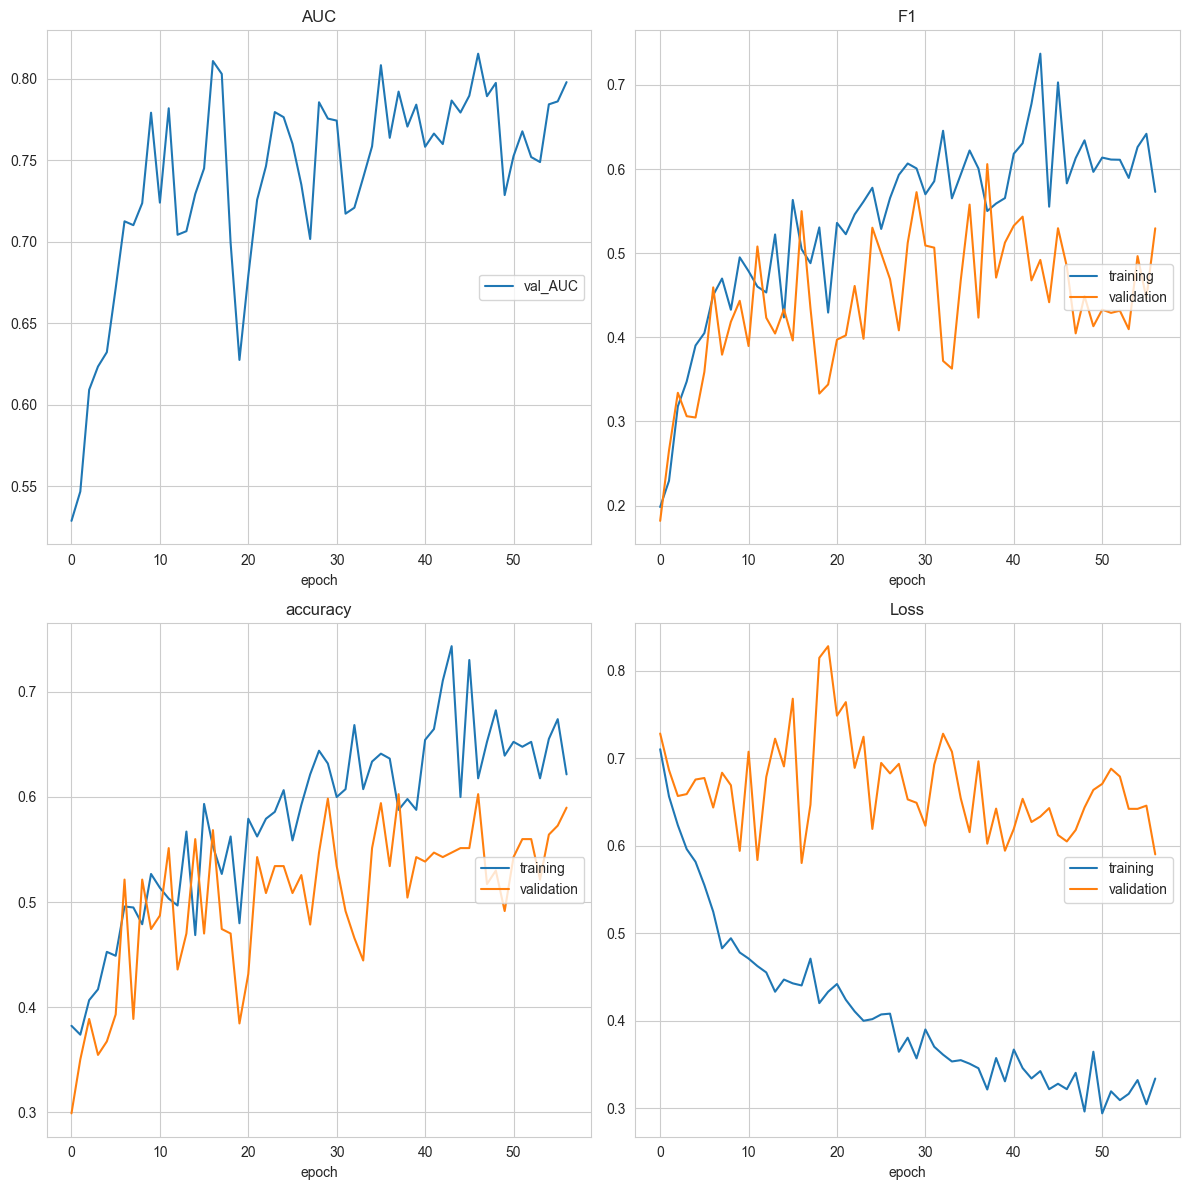

Early stopping at epoch 58 
 Best Val F1:    0.6059 
 Best Train F1:  0.5502 
 current Val F1: 0.4703 
 current Train F1: 0.6524 
 Best epoch: 38 


✓ Pesos restaurados para epoch 38 (Val F1: 0.6059)
train completed, best_metric: 0.6059 at epoch: 38
Time elapsed: 1196.6 seconds
Model saved as models\MIA_AP_my_models\densenet_v101_20260512_004928.pth


In [22]:
# AdamW com weight decay (regularização implícita)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# OneCycleLR: sobe LR rapidamente e depois desce com cosine — ideal para transfer learning
# Nota: actualiza a cada BATCH (não por epoch), por isso steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

val_interval = 1

starttime  = time.perf_counter()
model_name = get_versioned_model_name(model_name)
model      = train_model(train_loader, val_loader, model, optimizer, EPOCHS, model_name, scheduler)
endtime    = time.perf_counter()
print(f"Time elapsed: {endtime - starttime:.1f} seconds")
print(f"Model saved as {model_name}")

## Threshold Tuning por Classe (no Val Set)
Encontrar a escala óptima por classe para maximizar F1 macro antes de avaliar no test set.

In [23]:
def collect_probs_and_labels(loader, model, device):
    """Recolhe probabilidades softmax e labels verdadeiros."""
    all_probs  = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            probs  = torch.softmax(model(inputs), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.extend(labels.numpy())
    return np.vstack(all_probs), np.array(all_labels)


def tune_thresholds(probs, labels, num_classes, n_thresholds=50):
    """
    Grid search sobre escala de confiança por classe.
    Maximiza F1 macro no val set — especialmente útil para classes raras.
    """
    best_scale = np.ones(num_classes)
    scales     = np.linspace(0.5, 2.0, n_thresholds)

    for cls in range(num_classes):
        best_cls_f1 = -1
        best_s      = 1.0
        for s in scales:
            scale_vec       = best_scale.copy()
            scale_vec[cls]  = s
            preds = np.argmax(probs * scale_vec, axis=1)
            f1    = f1_score(labels, preds, average='macro', zero_division=0)
            if f1 > best_cls_f1:
                best_cls_f1 = f1
                best_s      = s
        best_scale[cls] = best_s
        print(f"  Classe {cls} ({class_names[cls]}): escala = {best_s:.3f}  →  F1 macro = {best_cls_f1:.4f}")

    final_f1 = f1_score(labels, np.argmax(probs * best_scale, axis=1), average='macro', zero_division=0)
    print(f"\n→ F1 macro val com threshold tuning: {final_f1:.4f}")
    return best_scale


print("A recolher probabilidades no val set...")
val_probs, val_labels_arr = collect_probs_and_labels(val_loader, model, device)

print("\nThreshold tuning por classe:")
best_scale = tune_thresholds(val_probs, val_labels_arr, num_class)

A recolher probabilidades no val set...

Threshold tuning por classe:
  Classe 0 (Biliary_Leaks): escala = 0.837  →  F1 macro = 0.6096
  Classe 1 (Lithiasis): escala = 1.051  →  F1 macro = 0.6151
  Classe 2 (Normal): escala = 0.653  →  F1 macro = 0.6319
  Classe 3 (Stricture): escala = 0.806  →  F1 macro = 0.6393

→ F1 macro val com threshold tuning: 0.6393


## Evaluation
Evaluate the model on the test set with TTA + threshold tuning, compute F1/accuracy and plot a confusion matrix.

A avaliar no test set com TTA + threshold tuning...
  TTA 1/4 concluído
  TTA 2/4 concluído
  TTA 3/4 concluído
  TTA 4/4 concluído

true: 0 pred: 0
true: 0 pred: 0
true: 0 pred: 0
true: 0 pred: 1
true: 0 pred: 0
true: 0 pred: 0
true: 0 pred: 0
true: 0 pred: 2
true: 0 pred: 0
true: 0 pred: 0
true: 0 pred: 3
Accuracy: 0.727
correct: 8 incorrect: 3
F1 Score (macro): 0.7076

               precision    recall  f1-score   support

Biliary_Leaks     0.9000    0.5294    0.6667        17
    Lithiasis     0.7830    0.6748    0.7249       123
       Normal     0.6154    0.7442    0.6737        43
    Stricture     0.7071    0.8333    0.7650        84

     accuracy                         0.7266       267
    macro avg     0.7514    0.6954    0.7076       267
 weighted avg     0.7396    0.7266    0.7256       267

[[ 9  1  3  4]
 [ 1 83 17 22]
 [ 0  8 32  3]
 [ 0 14  0 70]]


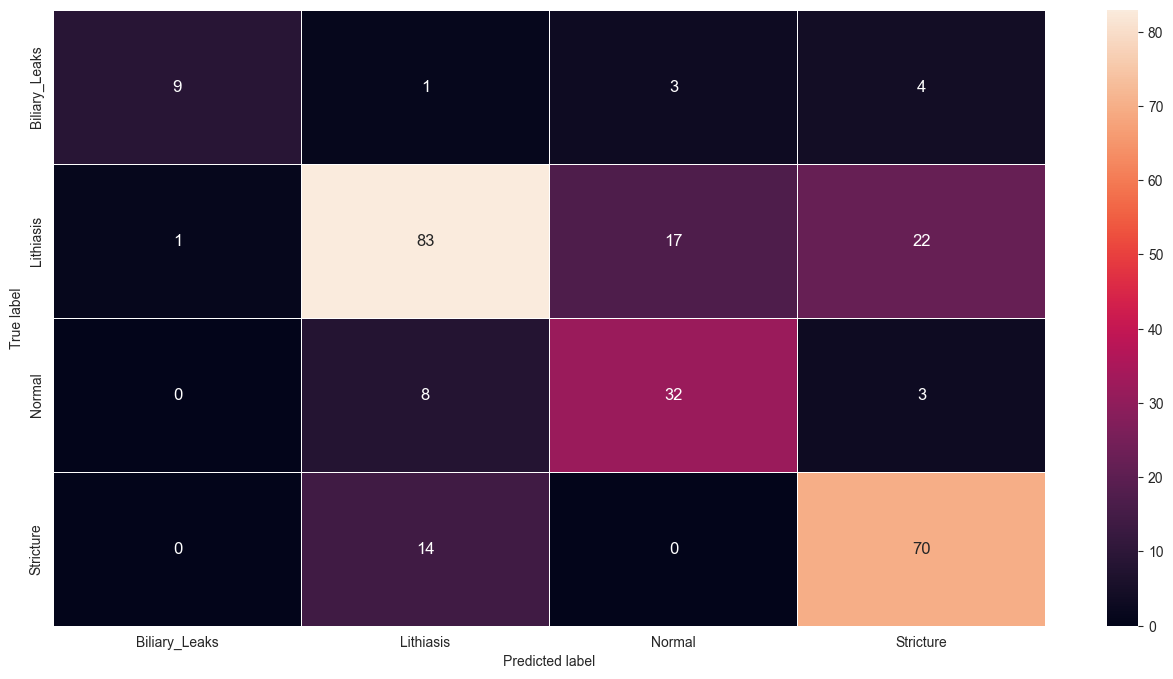

In [24]:
def evaluate_with_tta(image_files, labels_list, model, device, transforms_list, best_scale=None):
    """
    TTA: média das probabilidades de múltiplos augmentos.
    Aplica threshold tuning se best_scale for fornecido.
    """
    model.eval()
    all_probs = None

    for t_idx, t in enumerate(transforms_list):
        ds     = MedNISTDataset(image_files, labels_list, t)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
        probs_list = []
        with torch.no_grad():
            for inputs, _ in loader:
                inputs = inputs.to(device)
                probs  = torch.softmax(model(inputs), dim=1).cpu().numpy()
                probs_list.append(probs)
        probs_arr = np.vstack(probs_list)
        all_probs = probs_arr if all_probs is None else all_probs + probs_arr
        print(f"  TTA {t_idx+1}/{len(transforms_list)} concluído")

    all_probs /= len(transforms_list)

    all_probs_scaled = all_probs * best_scale if best_scale is not None else all_probs
    predictions      = np.argmax(all_probs_scaled, axis=1)
    actual           = np.array(labels_list)
    return actual, predictions, all_probs


def display_predictions(actual_values, predictions):
    right = wrong = primeiros = i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        right += (r == p)
        wrong += (r != p)
        i += 1
        if i > 10:
            break
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}')
    print(f'correct: {right} incorrect: {wrong}')
    f1 = f1_score(actual_values, predictions, average='macro', zero_division=0)
    print(f"F1 Score (macro): {f1:0.4f}")


def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes,
                annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()


# Avaliação final no test set com TTA + threshold tuning
print("A avaliar no test set com TTA + threshold tuning...")
actual_values, predictions, test_probs = evaluate_with_tta(
    data['test']['images'],
    data['test']['labels'],
    model, device,
    tta_transforms_list,
    best_scale=best_scale
)

# Resultados
print()
display_predictions(actual_values, predictions)

print()
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr           = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]
cm           = confusion_matrix(actual_values, predictions)
print(cm)
display_confusion_matrix(cm, list_classes, model_name)

In [25]:
# Resumo final
acc        = accuracy_score(actual_values, predictions)
f1_macro   = f1_score(actual_values, predictions, average='macro',    zero_division=0)
f1_weighted = f1_score(actual_values, predictions, average='weighted', zero_division=0)

print("="*50)
print(f"  RESULTADOS FINAIS — v1 F1Boost")
print("="*50)
print(f"  Accuracy:       {acc:.4f}")
print(f"  F1 Macro:       {f1_macro:.4f}  ← métrica principal")
print(f"  F1 Weighted:    {f1_weighted:.4f}")
print("="*50)
print(f"  Modelo: {model_name}")

  RESULTADOS FINAIS — v1 F1Boost
  Accuracy:       0.7266
  F1 Macro:       0.7076  ← métrica principal
  F1 Weighted:    0.7256
  Modelo: models\MIA_AP_my_models\densenet_v101_20260512_004928.pth
